# Atividade 2 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 10 de março de 2026

## Descrição

A atividade consiste em construir uma rede neural multilayer perceptron para distinguir atributos que definem a renda média de uma pessoa adulta a partir do _UCI Adult Income Dataset_

## Material de Referência para Estudo

- https://docs.pytorch.org/docs/stable/nn.html
- https://machinelearningmastery.com/develop-your-first-neural-network-with-pytorch-step-by-step/
- https://sebastianraschka.com/teaching/pytorch-1h/#7-a-typical-training-loop



## Trio

- Adriana Raffaella
- Davi Aguiar
- Henrique Furtado

In [23]:
# Bibliotecas
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from prettytable import PrettyTable
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Abertura e Análise Exploratória do Dataset

- A tarefa a ser considerada é uma tarefa de classificação binária, cujo objetivo é determinar se a renda média de uma pessoa adulta excedará os US $50,000 por ano.
- O dataset em questão pode ser obtido aqui: https://archive.ics.uci.edu/dataset/2/adult
- Faça uma pré-seleção dos exemplos, conforme sugerido pelos autores: (AAGE>16) && (AGI>100) && (AFNLWGT>1) && (HRSWK>0))
- Exclua todas as linhas com dados faltantes
- Quantos exemplos viáveis há no dataset?
- Preparação de atributos: todos os atributos categóricos devem ser codificados com One-Hot Encoding
- O dataset é balanceado?

In [24]:
# fetch dataset 
adult = fetch_ucirepo(id=2)

In [25]:
df_adult_original = adult.data.original
df_adult_original['income'] = df_adult_original['income'].str.replace(".", "", regex=False)
df_adult = df_adult_original.replace("?", pd.NA).dropna().copy()

In [26]:
# fnlwgt corresponde ao número de pessoas que aquela linha representa. Normalmente se utiliza uma normalização desse dado.
df_adult['afnlwgt'] = df_adult['fnlwgt'] / df_adult['fnlwgt'].mean()

#  AGI é a renda brunta
df_adult['agi'] = df_adult['capital-gain'] - df_adult['capital-loss']

df_adult = df_adult.drop(labels=['fnlwgt', 'capital-gain', 'capital-loss'], axis=1)

df_adult_clean = df_adult[(df_adult['age'] > 16) & (df_adult['afnlwgt'] > 1) & (df_adult['hours-per-week'] > 0) & (df_adult['agi'] > 100)]

print(f"Dataset antes de data engineerig: {df_adult_original.shape[0]}")
print(f"Dataset depois de data engineerig: {df_adult_clean.shape[0]}")

df_adult = pd.get_dummies(df_adult_clean, dtype=int)

Dataset antes de data engineerig: 48842
Dataset depois de data engineerig: 1551


In [27]:
df_adult.head()

,age,education-num,hours-per-week,afnlwgt,agi,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,income_<=50K,income_>50K
84,44,9,40,1.810902,14344,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
101,44,13,60,1.045049,15024,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
105,32,9,40,1.674232,7688,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
113,28,10,25,1.991565,4064,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
208,58,9,35,1.109776,15024,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1


In [28]:
df_adult.tail()

,age,education-num,hours-per-week,afnlwgt,agi,workclass_Federal-gov,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Poland,native-country_Portugal,native-country_Puerto-Rico,native-country_South,native-country_Taiwan,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,income_<=50K,income_>50K
48703,39,14,40,1.389782,3137,1,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
48745,59,13,40,1.870759,3103,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
48757,33,10,40,1.065451,2829,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
48770,29,9,45,1.519116,4386,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1
48822,40,15,55,1.065530,15024,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,1


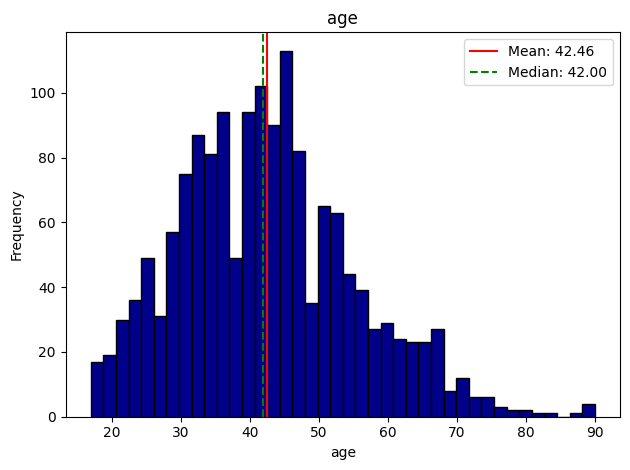

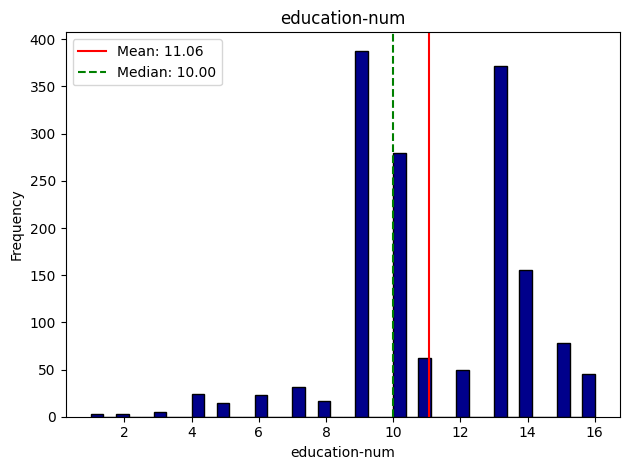

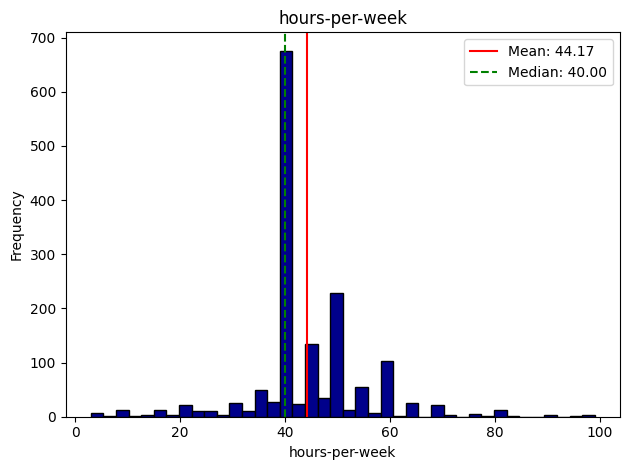

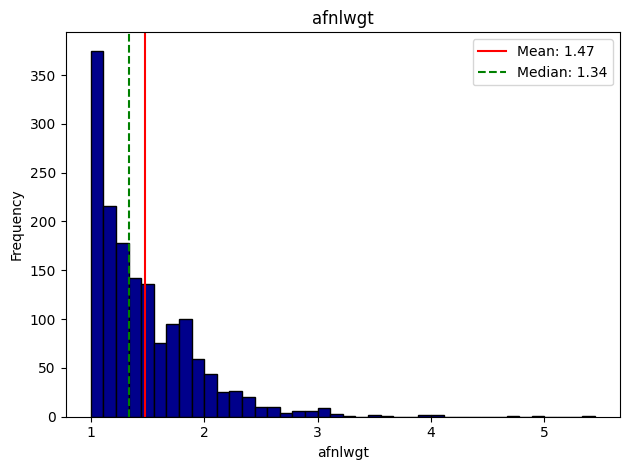

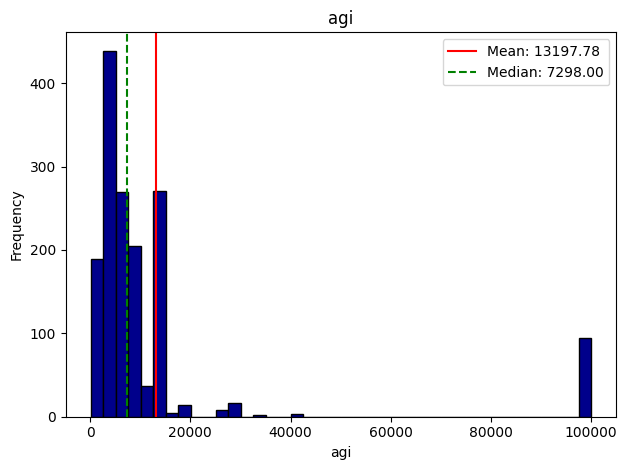

In [29]:
# Atributos númericos

num_features = ['age', 'education-num', 'hours-per-week', 'afnlwgt', 'agi']

for nf in num_features:
    mean = df_adult[nf].mean()
    median = df_adult[nf].median()

    plt.axvline(mean, color='red', linestyle="-", label=f'Mean: {mean:.2f}')
    plt.axvline(median, color='green', linestyle='--', label=f'Median: {median:.2f}')
    plt.hist(df_adult[nf], bins=40, edgecolor='black', color='darkblue')
    plt.title(nf)
    plt.xlabel(nf)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

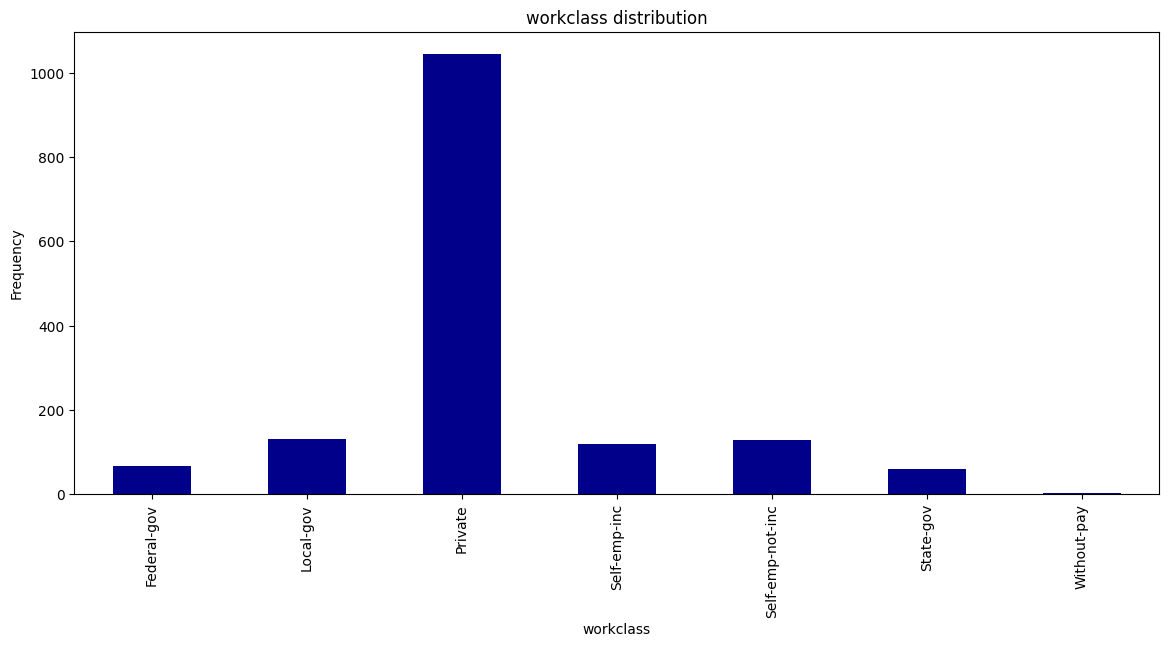

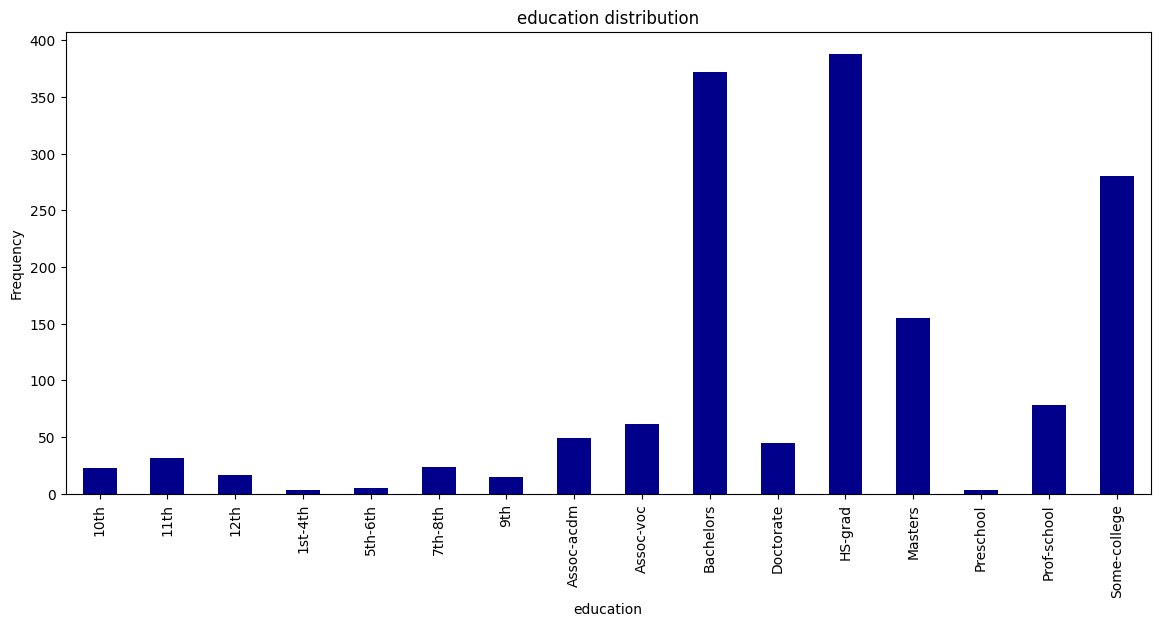

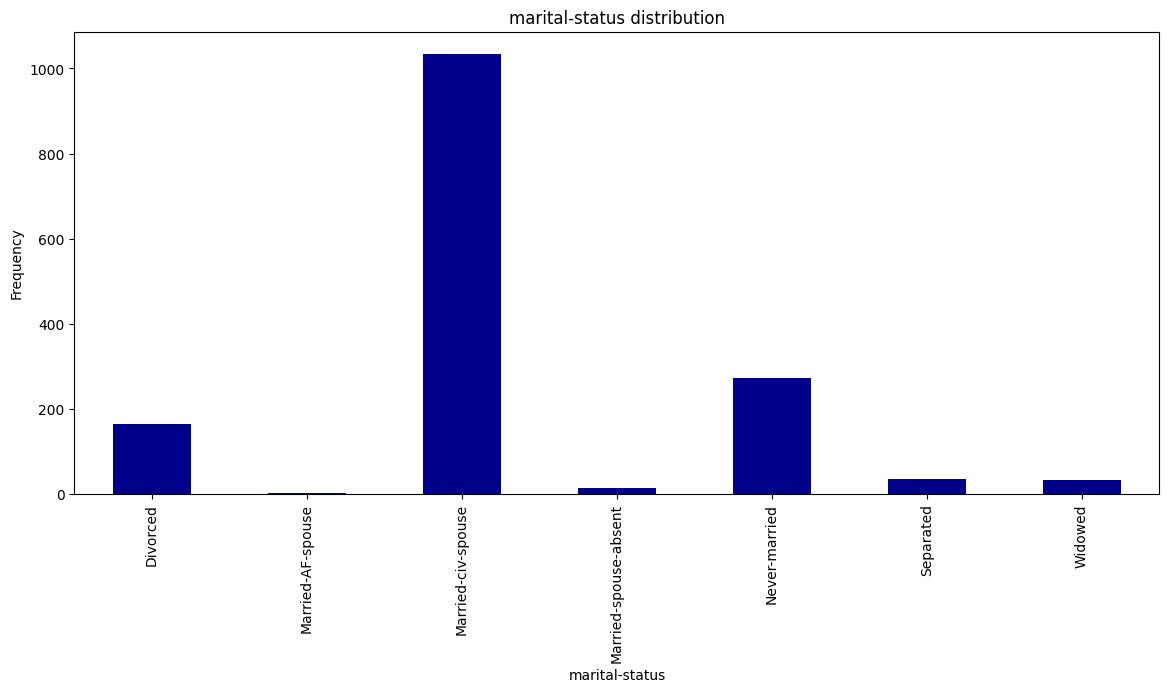

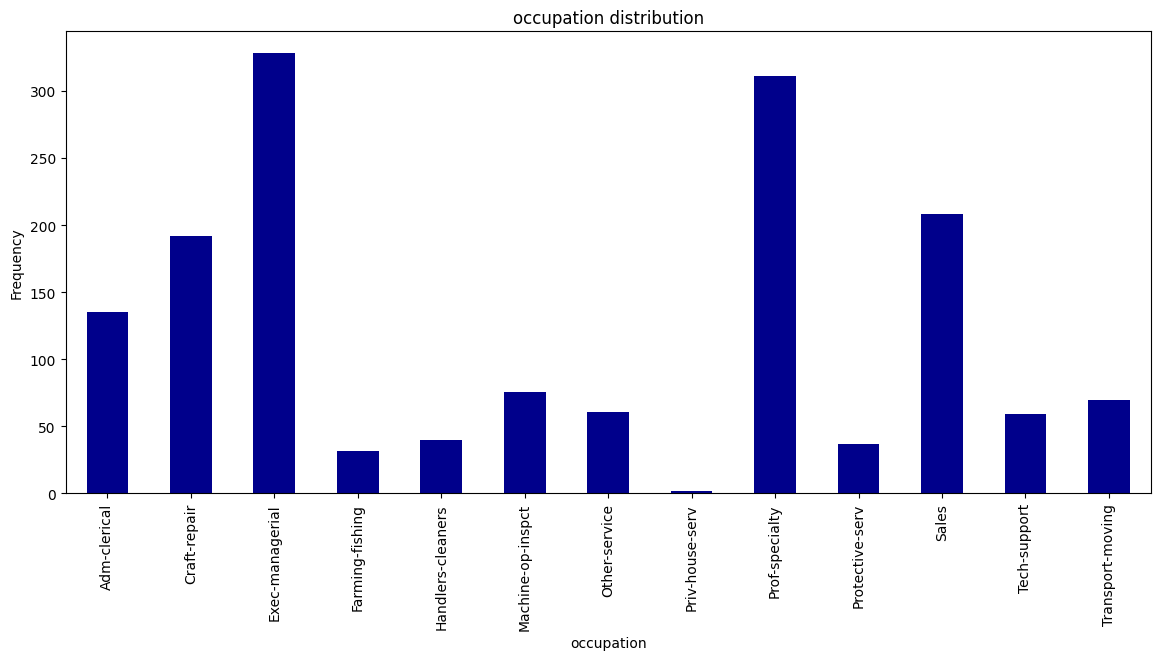

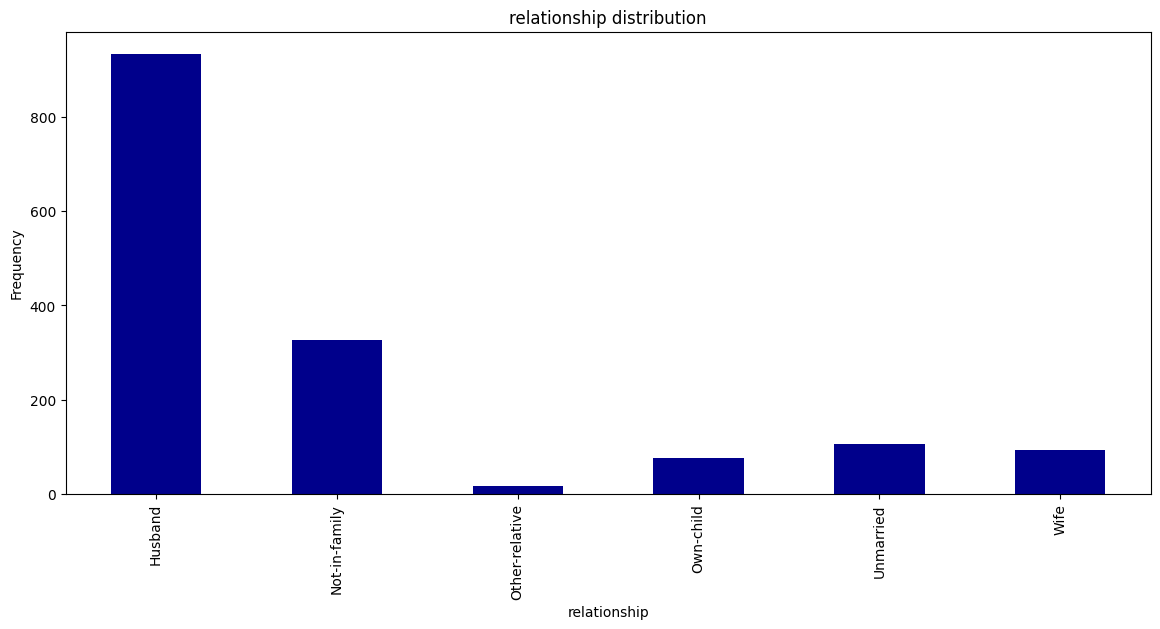

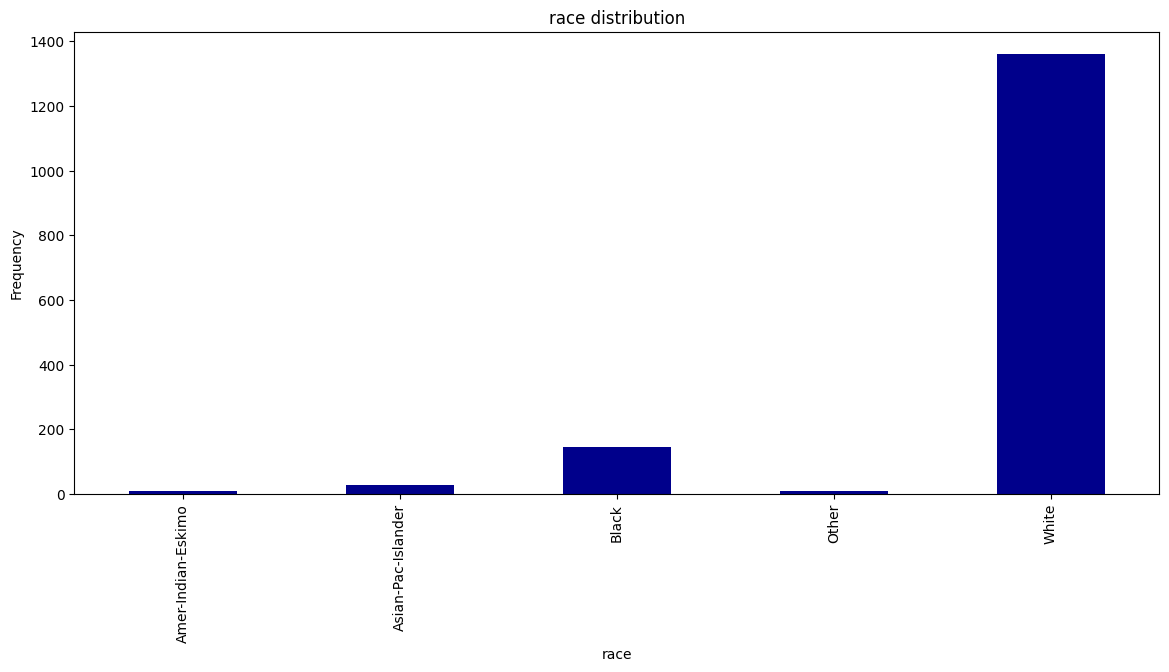

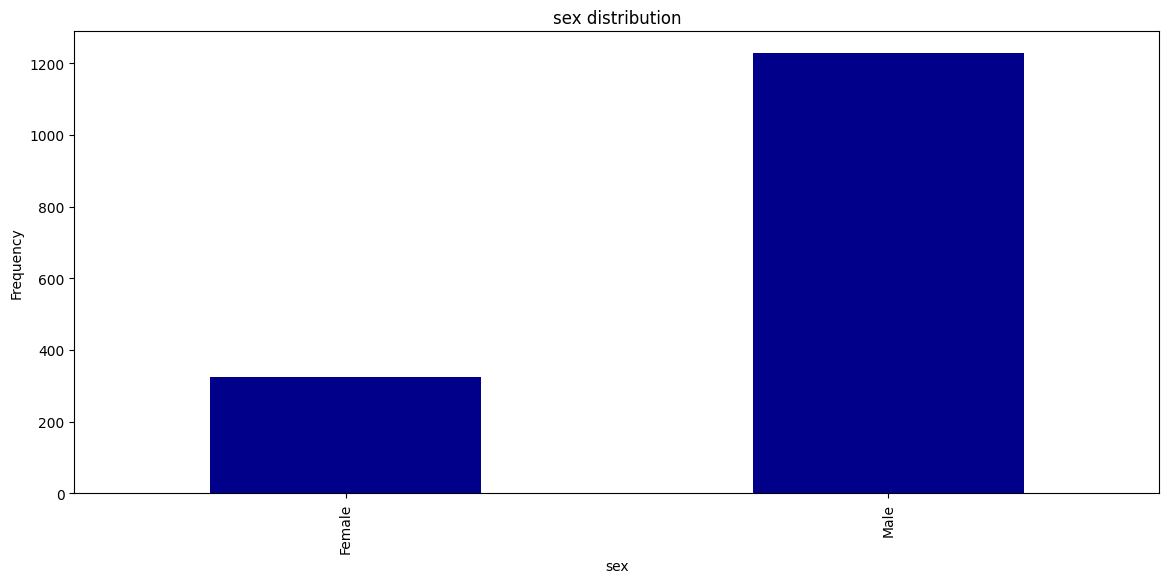

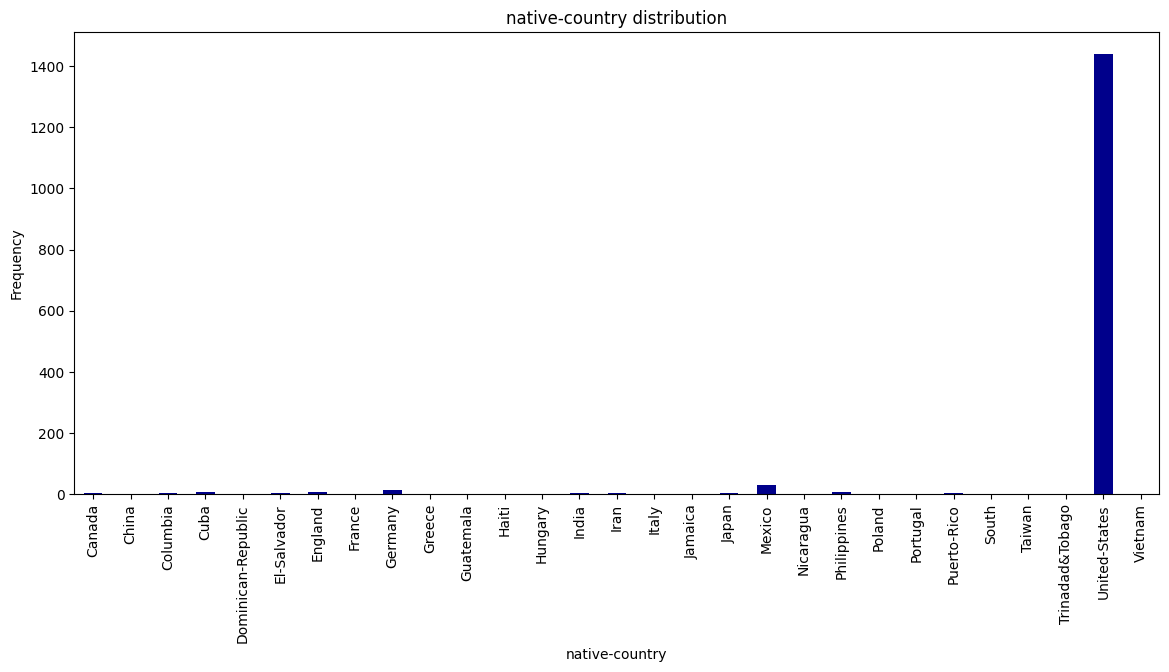

In [30]:
# Atributos categóricos

cat_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for cf in cat_features:
    df_adult_clean[cf].value_counts().sort_index().plot(kind='bar', color='darkblue', figsize=(14,6))
    plt.title(f'{cf} distribution')
    plt.xlabel(cf)
    plt.ylabel('Frequency')
    plt.show()

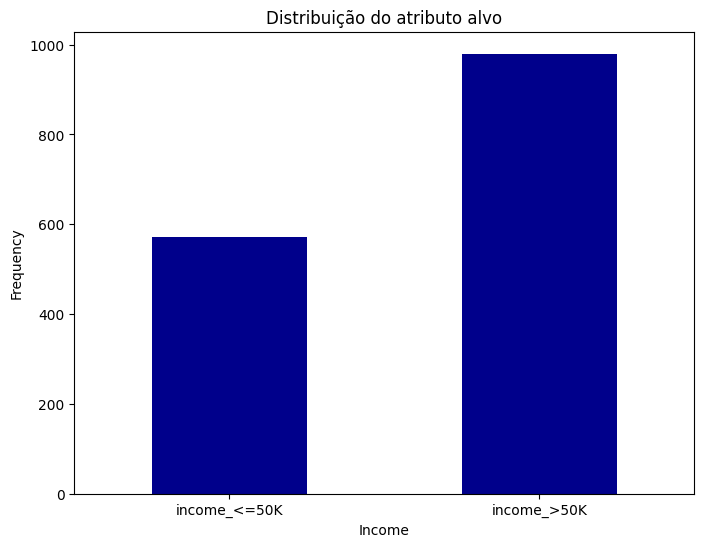

In [31]:
targerts = ['income_<=50K', 'income_>50K']

df_adult[[targerts[0], targerts[1]]].sum().plot(kind='bar', color='darkblue', figsize=(8,6))
plt.title('Distribuição do atributo alvo')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

##### Dataset desbalanceado! Praticamente todas as classes apresentam um desbalanceamento relevante para o treinamento, considerar esse desbalanceamento ao avaliar modelo.

## Preparação dos exemplos para treino e teste

- Separe os atributos preditores do atributo-alvo
- Faça uma partição do tipo holdout 70/30 de forma aleatória, use seed = 42
- Codifique os exemplos em tensores pytorch

In [32]:
X = df_adult.drop(labels=[targerts[0], targerts[1]], axis=1)
y = df_adult['income_>50K']

In [33]:
def holdout(X, y, state):
    return train_test_split(X, y, test_size=0.3, random_state=state)

X_train, X_test, y_train, y_test = holdout(X, y, 42)

In [34]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled).float()
X_test_tensor = torch.tensor(X_test_scaled).float()

y_train_tensor = torch.tensor(y_train.values).float().reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values).float().reshape(-1, 1)

## Rede MLP de Camada Única

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [35]:
class MLPSigleLayer(nn.Module):
    def __init__(self, input_size):
        super(MLPSigleLayer, self).__init__()
        self.hidden = nn.Linear(input_size, 100)
        self.relu = nn.ReLU()
        self.output = nn.Linear(100, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x
    
input_size = X_train_tensor.shape[1]
model = MLPSigleLayer(input_size)

epochs = 100
learning_rate = 1e-4
batch_size = 16

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

train_data = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)

losses = []

for epoch in range(epochs):
    epoch_loss = 0
    model.train()

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {losses[-1]:.4f}')

Epoch 10/100, Loss: 0.6991
Epoch 20/100, Loss: 0.6933
Epoch 30/100, Loss: 0.6875
Epoch 40/100, Loss: 0.6822
Epoch 50/100, Loss: 0.6768
Epoch 60/100, Loss: 0.6715
Epoch 70/100, Loss: 0.6666
Epoch 80/100, Loss: 0.6618
Epoch 90/100, Loss: 0.6569
Epoch 100/100, Loss: 0.6522


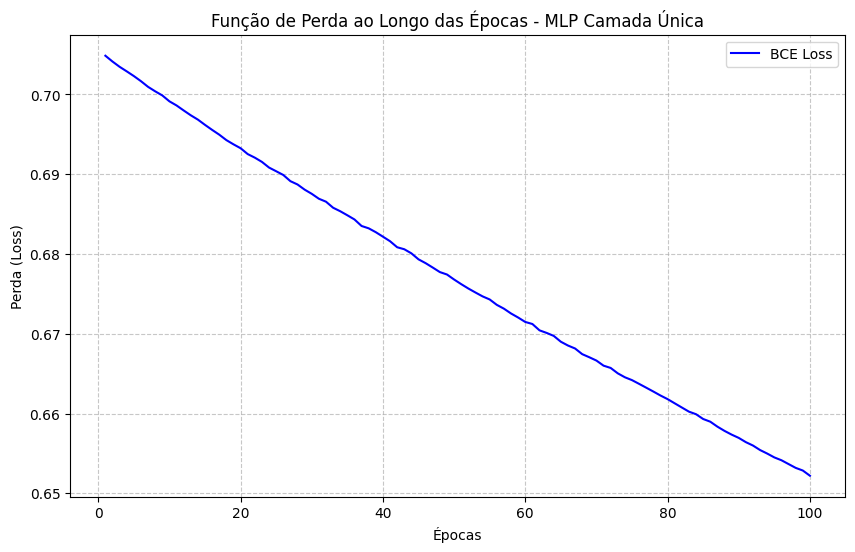

In [36]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses, color='blue', label='BCE Loss')
plt.title('Função de Perda ao Longo das Épocas - MLP Camada Única')
plt.xlabel('Épocas')
plt.ylabel('Perda (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Avaliação da MLP de Camada Única

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da rede perante essa tarefa?

In [37]:
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred = (y_pred_prob >= 0.5).float()

y_true_np = y_test_tensor.numpy()
y_pred_np = y_pred.numpy()

accuracy_balanced = balanced_accuracy_score(y_true_np, y_pred_np)
precision_balanced = precision_score(y_true_np, y_pred_np, average='macro', zero_division=0)
recall_balanced = recall_score(y_true_np, y_pred_np, average='macro')
f1_balanced = f1_score(y_true_np, y_pred_np, average='macro')

results_table = PrettyTable()
results_table.field_names = ["Métrica", "Resultado"]
results_table.add_row(["Acurácia Balanceada", f"{accuracy_balanced:.4f}"])
results_table.add_row(["Precisão Balanceada", f"{precision_balanced:.4f}"])
results_table.add_row(["Recall Balanceado", f"{recall_balanced:.4f}"])
results_table.add_row(["F1-Score Balanceado", f"{f1_balanced:.4f}"])

results_table.align["Métrica"] = "l"
results_table.align["Resultado"] = "r"
print("Avaliação da MLP de Camada Única")
print(results_table)

Avaliação da MLP de Camada Única
+---------------------+-----------+
| Métrica             | Resultado |
+---------------------+-----------+
| Acurácia Balanceada |    0.6054 |
| Precisão Balanceada |    0.6789 |
| Recall Balanceado   |    0.6054 |
| F1-Score Balanceado |    0.6028 |
+---------------------+-----------+


<Figure size 600x500 with 0 Axes>

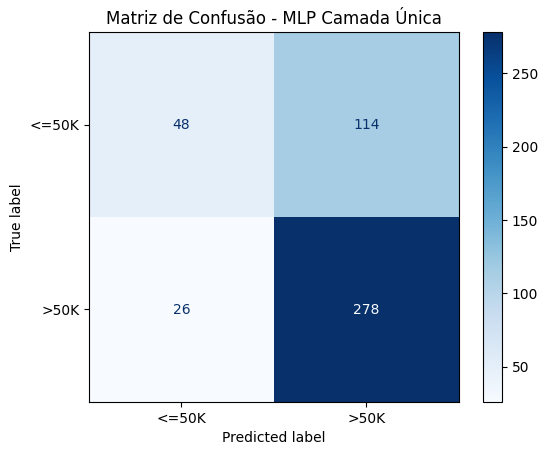

In [38]:
cm = confusion_matrix(y_true_np, y_pred_np)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<=50K', '>50K'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusão - MLP Camada Única')
plt.show()

O desempenho da rede foi insatisfatório para fins práticos, porque mesmo tendo uma acurácia balanceada de 63,5%, a matriz de confusão mostra que o modelo identificou corretamente apenas 6,4% da classe de renda superior, sendo assim, incapaz de fazer uma predição adequada do problema. Mas, os resultados são coerentes com as limitações que foram impostas nos hiperparâmetros (taxa de aprendizado baixa e poucas épocas) e pela natureza desbalanceada do dataset, que induziu o modelo a priorizar a classe majoritária para reduzir a perda, de forma superficial.

## Rede MLP com duas camadas ocultas

- Proponha uma rede neural multilayer perceptron no Pytorch cujo número de neurônios dá-se como segue:
    - Camada de entrada: quantidade de atributos preditores
    - Camada oculta 1: 100 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada oculta 2: 50 neurônios (Linear)
    - Função de ativação: ReLU
    - Camada de saída: 1 neurônio com função de ativação sigmoidal (usar degrau em 0.5)
    - Função de Perda: Entropia cruzada binária
- Hiperparâmetros:
   - Épocas: 100
   - Taxa de aprendizado: 10^-4
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

In [39]:
class MLPMultiLayer(nn.Module):
    def __init__(self, input_size):
        super(MLPMultiLayer, self).__init__()
        self.hidden1 = nn.Linear(input_size, 100)
        self.relu1 = nn.ReLU()
        self.hidden2 = nn.Linear(100, 50)
        self.relu2 = nn.ReLU()
        self.output = nn.Linear(50, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu1(self.hidden1(x))
        x = self.relu2(self.hidden2(x))
        x = self.sigmoid(self.output(x))
        return x
    
input_size = X_train_tensor.shape[1]
model_multi = MLPMultiLayer(input_size)
optimizer_multi = optim.SGD(model_multi.parameters(), lr=learning_rate)

losses_multi = []

for epoch in range(epochs):
    epoch_loss = 0
    model_multi.train()

    for X_batch, y_batch in train_loader:
        optimizer_multi.zero_grad()
        outputs = model_multi(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_multi.step()
        epoch_loss += loss.item()

    losses_multi.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {losses_multi[-1]:.4f}')

Epoch 10/100, Loss: 0.6988
Epoch 20/100, Loss: 0.6969
Epoch 30/100, Loss: 0.6951
Epoch 40/100, Loss: 0.6934
Epoch 50/100, Loss: 0.6916
Epoch 60/100, Loss: 0.6900
Epoch 70/100, Loss: 0.6885
Epoch 80/100, Loss: 0.6869
Epoch 90/100, Loss: 0.6854
Epoch 100/100, Loss: 0.6840


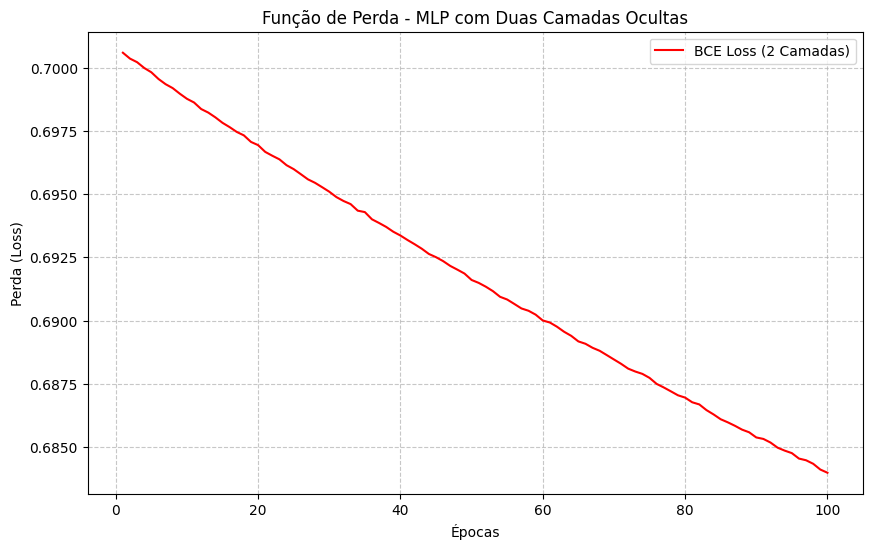

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), losses_multi, color='red', label='BCE Loss (2 Camadas)')
plt.title('Função de Perda - MLP com Duas Camadas Ocultas')
plt.xlabel('Épocas')
plt.ylabel('Perda (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

### Avaliação da MLP com Duas Camadas Ocultas

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste
- Avalie de forma crítica: Como foi o desempenho da nova rede perante essa tarefa? Houve melhora?

In [42]:
model_multi.eval()

with torch.no_grad():
    y_pred_prob_multi = model_multi(X_test_tensor)
    y_pred_multi = (y_pred_prob_multi >= 0.5).float()

y_pred_np_multi = y_pred_multi.numpy()

accuracy_balanced_multi = balanced_accuracy_score(y_true_np, y_pred_np_multi)
precision_balanced_multi = precision_score(y_true_np, y_pred_np_multi, average='macro', zero_division=0)
recall_balanced_multi = recall_score(y_true_np, y_pred_np_multi, average='macro')
f1_balanced_multi = f1_score(y_true_np, y_pred_np_multi, average='macro') 

results_table_multi = PrettyTable()
results_table_multi.field_names = ["Métrica", "Resultado"]
results_table_multi.add_row(["Acurácia Balanceada", f"{accuracy_balanced_multi:.4f}"])
results_table_multi.add_row(["Precisão Balanceada", f"{precision_balanced_multi:.4f}"])
results_table_multi.add_row(["Recall Balanceado", f"{recall_balanced_multi:.4f}"])
results_table_multi.add_row(["F1-Score Balanceado", f"{f1_balanced_multi:.4f}"])

results_table_multi.align["Métrica"] = "l"
results_table_multi.align["Resultado"] = "r"
print("Avaliação da MLP com Duas Camadas Ocultas")
print(results_table_multi)

Avaliação da MLP com Duas Camadas Ocultas
+---------------------+-----------+
| Métrica             | Resultado |
+---------------------+-----------+
| Acurácia Balanceada |    0.5014 |
| Precisão Balanceada |    0.5765 |
| Recall Balanceado   |    0.5014 |
| F1-Score Balanceado |    0.4006 |
+---------------------+-----------+


<Figure size 600x500 with 0 Axes>

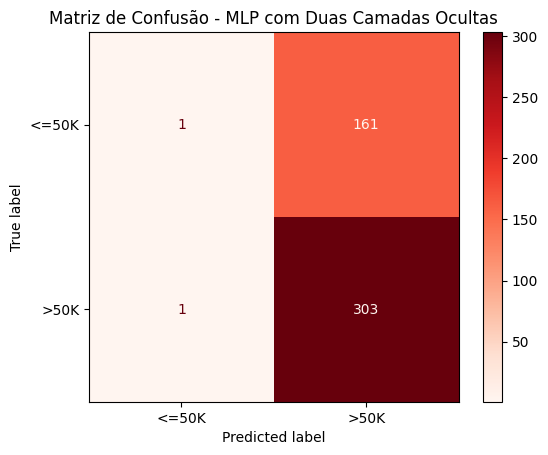

In [43]:
cm_multi = confusion_matrix(y_true_np, y_pred_np_multi)
disp_multi = ConfusionMatrixDisplay(confusion_matrix=cm_multi, display_labels=['<=50K', '>50K'])
plt.figure(figsize=(6, 5))
disp_multi.plot(cmap='Reds', values_format='d')
plt.title('Matriz de Confusão - MLP com Duas Camadas Ocultas')
plt.show()

O desempenho da nova rede foi inferior ao modelo anterior e insatisfatório para fins práticos, porque, com uma acurácia balanceada de apenas 50,1%, a rede perdeu quase toda a sua capacidade de distinção, conseguindo identificar corretamente apenas 1 único exemplo da classe de renda superior em todo o conjunto de teste. Não houve melhora, pelo contrário, houve uma regressão, pois a adição da segunda camada exigiria um esforço de treinamento muito superior para ajustar o novo volume de parâmetros. Sob as mesmas limitações impostas, a rede não conseguiu sair do estado inicial, resultando em um underfitting ainda maior que o da rede de camada única e em uma entrega total ao viés da classe majoritária.

## Sua rede MLP

- Proponha uma rede neural multilayer perceptron no Pytorch com uma ou duas camadas ocultas e número de neurônios conforme sua livre escolha, levando em conta razoabilidade,  tempo de execução no hardware disponível e prazo de entrega da atividade
- Hiperparâmetros:
   - Modifique-os como desejar
- Treine a rede com a partição reservada para essa finalidade
    - Otimizador: Mini-batch SGD com batch size de 16
- Mostre o gráfico da função de perda ao longo das épocas

### Avaliação da sua rede MLP

- Obtenha as métricas de desempenho para a partição de testes
  1. Acurácia balanceada
  2. Precisão balanceada
  3. Revocação balanceada
  4. F1-Score balanceado
- Imprima a matriz de confusão do teste

## Análise Comparativa Final

Construa uma tabela (pacote prettytable) com as métricas de desempenho das três redes propostas na partição de testes e justifique, com base em argumentos de performance, eficiência e aderência ao problema, qual delas possivelmente obteve melhor desempenho na tarefa.